In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

dias = pd.date_range(
    start="2025-01-01",
    end="2025-06-30"
)

vendas = np.random.normal(
    loc=5000,
    scale=700,
    size=len(dias)
)

# Campanha em junho
vendas[-30:] += 800

df = pd.DataFrame({
    "data": dias,
    "vendas": vendas
})

df.head()

,data,vendas
0,2025-01-01,5347.699907
1,2025-01-02,4903.214989
2,2025-01-03,5453.381977
3,2025-01-04,6066.120899
4,2025-01-05,4836.092638


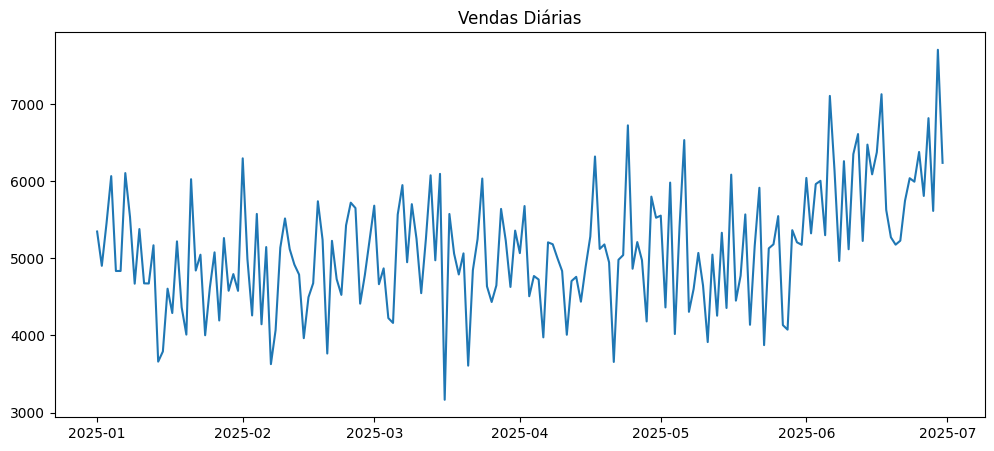

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["data"], df["vendas"])
plt.title("Vendas Diárias")
plt.show()

In [3]:
df["vendas"].describe()

,vendas
count,181.000000
mean,5119.603122
std,766.731018
min,3166.178427
25%,4637.210847
50%,5119.957797
75%,5575.331753
max,7704.118417


In [4]:
#adicionando um nova variável mas com números na faixa de dezenas de milhares
df["acessos_site"] = np.random.randint(
    10000,
    50000,
    len(df)
)

In [5]:
df.head()

,data,vendas,acessos_site
0,2025-01-01,5347.699907,47410
1,2025-01-02,4903.214989,18208
2,2025-01-03,5453.381977,28589
3,2025-01-04,6066.120899,27453
4,2025-01-05,4836.092638,46212


In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["vendas_norm",
    "acessos_norm"]] = scaler.fit_transform(
    df[["vendas","acessos_site"]]
)

In [7]:
df.head()

,data,vendas,acessos_site,vendas_norm,acessos_norm
0,2025-01-01,5347.699907,47410,0.480729,0.935552
1,2025-01-02,4903.214989,18208,0.382781,0.201538
2,2025-01-03,5453.381977,28589,0.504018,0.462472
3,2025-01-04,6066.120899,27453,0.639044,0.433918
4,2025-01-05,4836.092638,46212,0.367989,0.905439


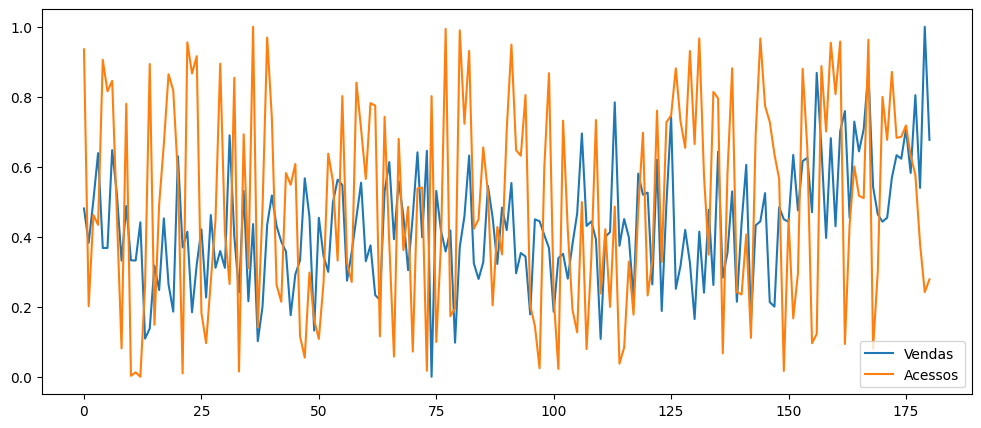

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df["vendas_norm"])
plt.plot(df["acessos_norm"])

plt.legend([
    "Vendas",
    "Acessos"
])

plt.show()

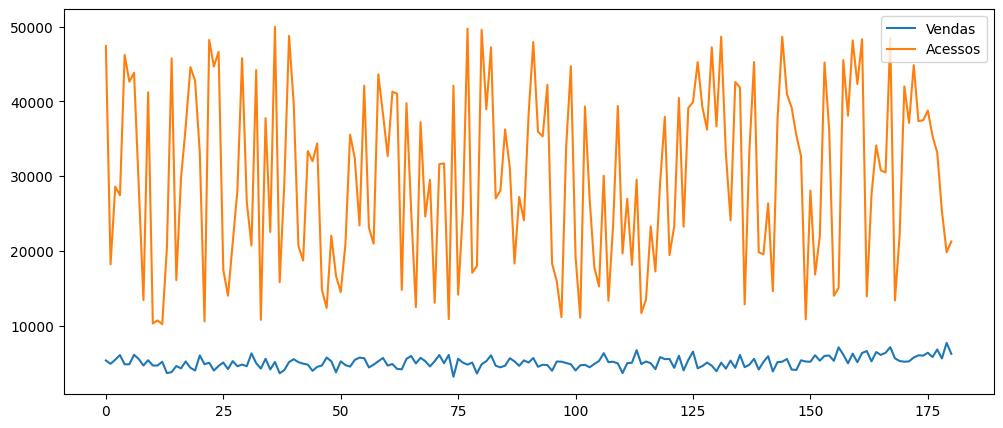

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df["vendas"])
plt.plot(df["acessos_site"])

plt.legend([
    "Vendas",
    "Acessos"
])

plt.show()

In [10]:
from scipy.stats import zscore

df["vendas_z"] = zscore(
    df["vendas"]
)

In [11]:
df.head()

,data,vendas,acessos_site,vendas_norm,acessos_norm,vendas_z
0,2025-01-01,5347.699907,47410,0.480729,0.935552,0.298318
1,2025-01-02,4903.214989,18208,0.382781,0.201538,-0.283005
2,2025-01-03,5453.381977,28589,0.504018,0.462472,0.436535
3,2025-01-04,6066.120899,27453,0.639044,0.433918,1.237909
4,2025-01-05,4836.092638,46212,0.367989,0.905439,-0.370791


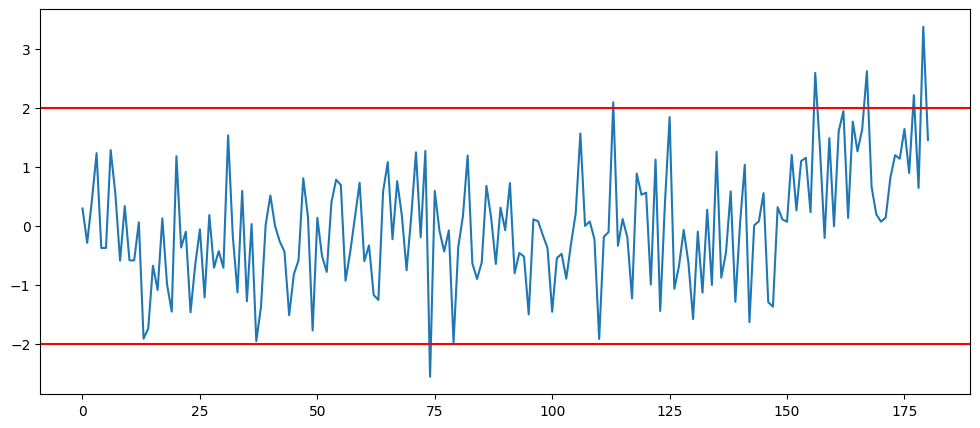

In [12]:
plt.figure(figsize=(12,5))

plt.plot(df["vendas_z"])

plt.axhline(2,color="red")
plt.axhline(-2,color="red")

plt.show()

In [13]:
df["media_movel"] = (
    df["vendas"]
    .rolling(window=7)
    .mean()
)

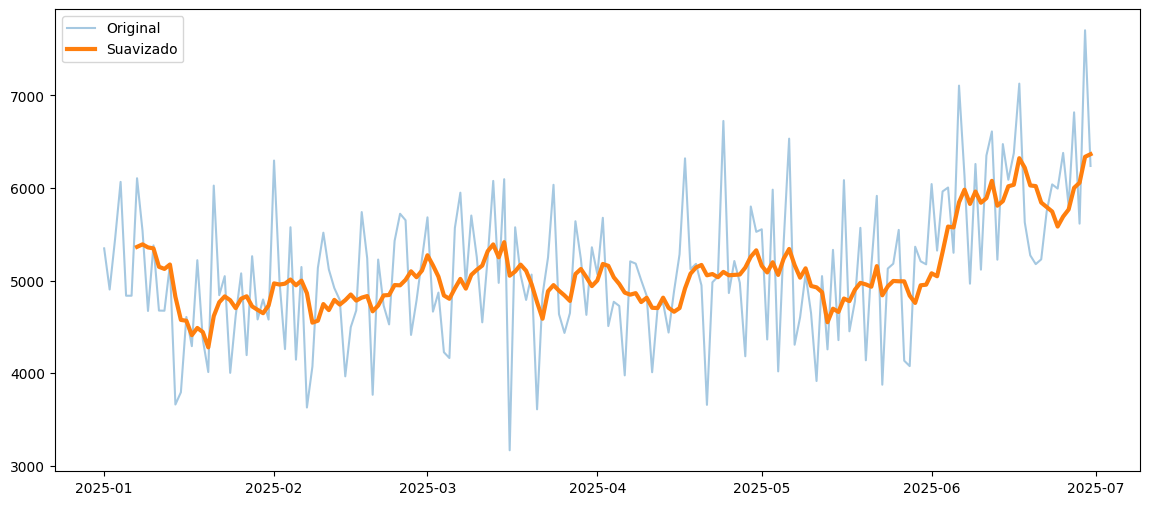

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df["data"],
         df["vendas"],
         alpha=0.4)

plt.plot(df["data"],
         df["media_movel"],
         linewidth=3)

plt.legend([
    "Original",
    "Suavizado"
])

plt.show()

In [16]:
amostra = df["vendas"].sample(
    50,
    random_state=42
)

In [17]:
from scipy import stats

ic = stats.t.interval(
    confidence=0.95,
    df=len(amostra)-1,
    loc=amostra.mean(),
    scale=stats.sem(amostra)
)

ic

(np.float64(4909.305256326414), np.float64(5311.279966575432))

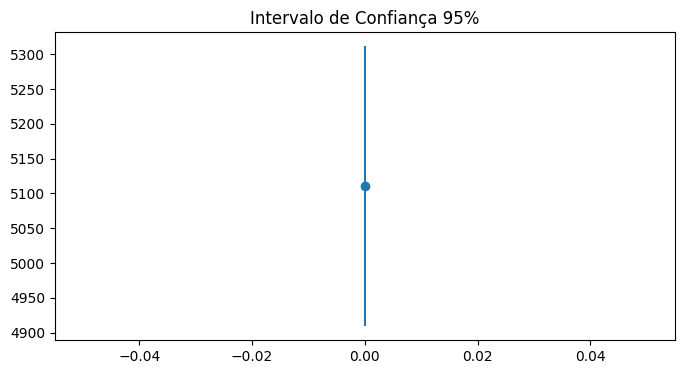

In [18]:
media = amostra.mean()

plt.figure(figsize=(8,4))

plt.errorbar(
    x=0,
    y=media,
    yerr=[[media-ic[0]],
          [ic[1]-media]],
    fmt='o'
)

plt.title(
    "Intervalo de Confiança 95%"
)

plt.show()

In [19]:
antes = df.iloc[:-30]["vendas"]

depois = df.iloc[-30:]["vendas"]

In [20]:
from scipy.stats import ttest_ind

estatistica,p = ttest_ind(
    antes,
    depois
)

print(p)

1.1209236871941246e-13


In [21]:
if p < 0.05:
    print(
      "Rejeitamos H0"
    )
else:
    print(
      "Não rejeitamos H0"
    )

Rejeitamos H0


<Axes: xlabel='periodo', ylabel='valor'>

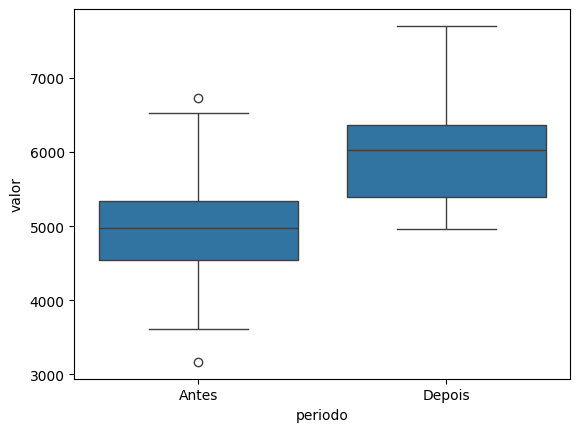

In [22]:
import seaborn as sns

comparacao = pd.DataFrame({
    "valor":
    list(antes)+list(depois),

    "periodo":
    ["Antes"]*len(antes)
    +
    ["Depois"]*len(depois)
})

sns.boxplot(
    data=comparacao,
    x="periodo",
    y="valor"
)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Separando os períodos
antes = df.iloc[:-40]["vendas"]
depois = df.iloc[-40:]["vendas"]

# Teste t
t_stat, p = stats.ttest_ind(antes, depois)

# Intervalo de confiança (95%)
ic_antes = stats.t.interval(
    confidence=0.95,
    df=len(antes)-1,
    loc=antes.mean(),
    scale=stats.sem(antes)
)

ic_depois = stats.t.interval(
    confidence=0.95,
    df=len(depois)-1,
    loc=depois.mean(),
    scale=stats.sem(depois)
)

# Crescimento percentual
crescimento = ((depois.mean() - antes.mean()) / antes.mean()) * 100

# Tabela resumo
dashboard = pd.DataFrame({
    "Indicador": [
        "Média Antes",
        "Média Depois",
        "Crescimento (%)",
        "Desvio Padrão Antes",
        "Desvio Padrão Depois",
        "IC 95% Antes",
        "IC 95% Depois",
        "p-valor",
        "Conclusão"
    ],
    "Resultado": [
        f"R$ {antes.mean():,.2f}",
        f"R$ {depois.mean():,.2f}",
        f"{crescimento:.2f} %",
        f"R$ {antes.std():,.2f}",
        f"R$ {depois.std():,.2f}",
        f"R$ {ic_antes[0]:,.2f} até R$ {ic_antes[1]:,.2f}",
        f"R$ {ic_depois[0]:,.2f} até R$ {ic_depois[1]:,.2f}",
        f"{p:.5f}",
        "Rejeita H₀" if p < 0.05 else "Não rejeita H₀"
    ]
})

print(dashboard)

              Indicador                    Resultado
0           Média Antes                  R$ 4,942.73
1          Média Depois                  R$ 5,743.09
2       Crescimento (%)                      16.19 %
3   Desvio Padrão Antes                    R$ 658.11
4  Desvio Padrão Depois                    R$ 804.18
5          IC 95% Antes  R$ 4,833.15 até R$ 5,052.30
6         IC 95% Depois  R$ 5,485.91 até R$ 6,000.28
7               p-valor                      0.00000
8             Conclusão                   Rejeita H₀


In [25]:
from IPython.display import display

display(dashboard)

,Indicador,Resultado
0,Média Antes,"R$ 4,942.73"
1,Média Depois,"R$ 5,743.09"
2,Crescimento (%),16.19 %
3,Desvio Padrão Antes,R$ 658.11
4,Desvio Padrão Depois,R$ 804.18
5,IC 95% Antes,"R$ 4,833.15 até R$ 5,052.30"
6,IC 95% Depois,"R$ 5,485.91 até R$ 6,000.28"
7,p-valor,0.00000
8,Conclusão,Rejeita H₀


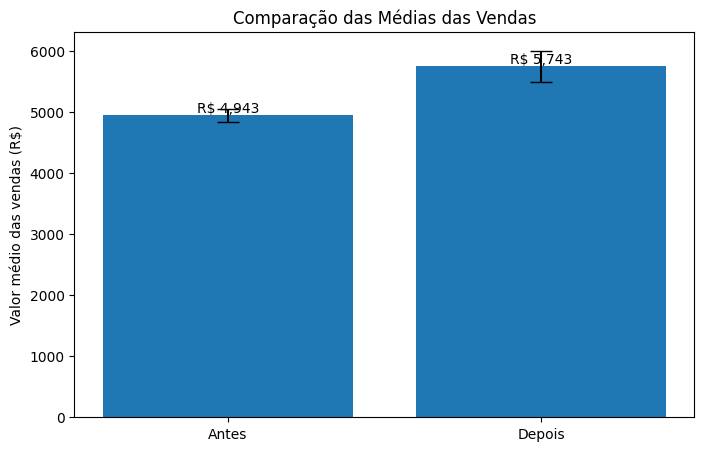

In [26]:
plt.figure(figsize=(8,5))

medias = [antes.mean(), depois.mean()]
erros = [
    antes.mean() - ic_antes[0],
    depois.mean() - ic_depois[0]
]

plt.bar(
    ["Antes", "Depois"],
    medias,
    yerr=erros,
    capsize=8
)

plt.title("Comparação das Médias das Vendas")
plt.ylabel("Valor médio das vendas (R$)")

for i, valor in enumerate(medias):
    plt.text(
        i,
        valor + 50,
        f"R$ {valor:,.0f}",
        ha="center",
        fontsize=10
    )

plt.show()